# SINDy on the Lotka–Volterra system

1. Simulate the true Lotka–Volterra system (Euler integration) to get ground-truth data.
2. Build the candidate function library $\Theta(X)$.
3. Fit a **dense** least-squares model (baseline — no sparsity yet).
4. Run **sequential thresholded least squares (STLS)** to convert it into a sparse model.
5. Compare the recovered coefficients to the true ones, and validate by re-simulating.

## 1. Imports

In [20]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=10, suppress=True)

## 2. True Lotka–Volterra parameters

These are the ground-truth values we will later try to *recover* purely from
simulated data — nothing downstream is allowed to "cheat" by looking at these
directly except the final comparison step.

In [21]:
alpha = 1.0     # prey growth rate
beta  = 0.02    # predation rate
gamma = 0.4     # predator death rate
delta = 0.02    # predator growth rate from predation

## 3. The governing equations

$$\dot x = \alpha x - \beta xy \qquad \dot y = \delta xy - \gamma y$$

Each equation has exactly **two** nonzero terms — this is the sparsity we're hoping
the regression rediscovers later, without being told the equations directly.

In [22]:
def dxdt(x, y):  # prey (x) dynamics
    return alpha * x - beta * x * y

def dydt(x, y):  # predator (y) dynamics
    return delta * x * y - gamma * y

## 4. Time grid and storage

A small step size `h` keeps the forward-Euler integration reasonably accurate.
Recall Euler doesn't exactly conserve the orbit — for a long run like this it will
drift slightly, but it's fine as a from-scratch data source for SINDy.

In [23]:
h = 0.001
t = np.arange(0, 200, h)
m = len(t)  # number of time samples

x, y = np.zeros(m), np.zeros(m)
x_dot, y_dot = np.zeros(m), np.zeros(m)

## 5. Initial condition

In [24]:
x[0], y[0] = 40.0, 9.0

## 6. Forward-Euler integration loop

At each step we evaluate the *true* right-hand side to get $\dot x, \dot y$
(this is our ground-truth derivative — no finite-difference noise here), then
take an Euler step to advance the state.

In [25]:
for i in range(m - 1):
    x_dot[i] = dxdt(x[i], y[i])
    y_dot[i] = dydt(x[i], y[i])

    x[i+1] = x[i] + h * x_dot[i]
    y[i+1] = y[i] + h * y_dot[i]

# derivative at the final sample (never assigned inside the loop)
x_dot[-1] = dxdt(x[-1], y[-1])
y_dot[-1] = dydt(x[-1], y[-1])

## 7. Sanity-check plots

Time series should show the classic oscillating predator/prey cycles; phase space
should show a closed-ish loop (slightly open due to Euler drift over a long run).

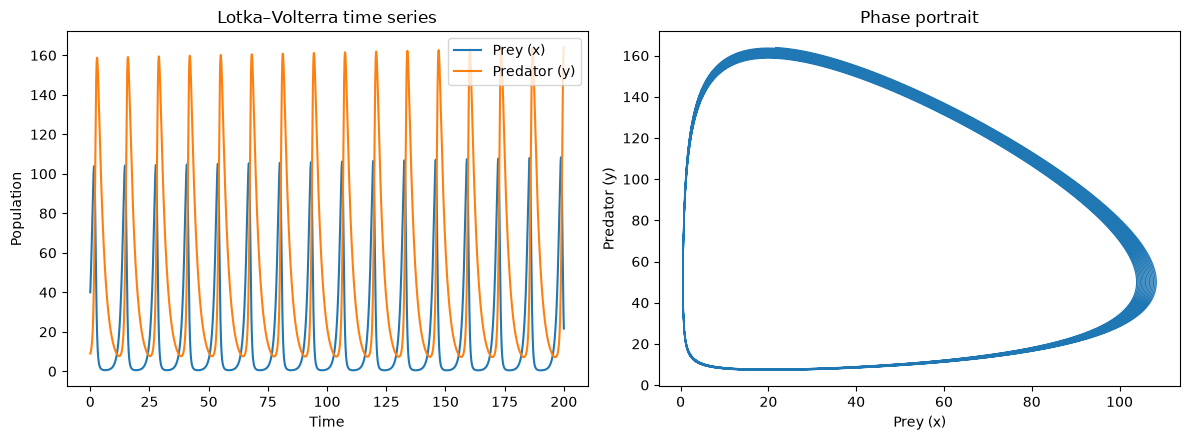

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(t, x, label='Prey (x)')
axes[0].plot(t, y, label='Predator (y)')
axes[0].set_xlabel('Time'); axes[0].set_ylabel('Population')
axes[0].set_title('Lotka–Volterra time series'); axes[0].legend()

axes[1].plot(x, y, lw=0.8)
axes[1].set_xlabel('Prey (x)'); axes[1].set_ylabel('Predator (y)')
axes[1].set_title('Phase portrait')

plt.tight_layout(); plt.show()

## 8. Assemble the data matrices $X$ and $\dot X$

Row $i$ of `X` is the state $(x_i, y_i)$ at time $t_i$; row $i$ of `X_dot` is
the matching derivative $(\dot x_i, \dot y_i)$. This is exactly the $X,\dot X$
notation from the SINDy setup.

In [27]:
X = np.vstack((x, y)).T          # shape (m, 2)
X_dot = np.vstack((x_dot, y_dot)).T   # shape (m, 2) — what we want to recover from X
X.shape, X_dot.shape

((200000, 2), (200000, 2))

## 9. Candidate function library $\Theta(X)$

This is the "menu" of candidate terms the sparse regression is allowed to choose
from. It's deliberately over-inclusive — polynomials up to cubic, plus a couple of
trig terms — so the true LV terms ($x$, $y$, $xy$) are in there, but so are many
terms that should end up with a coefficient of exactly zero.

In [28]:
# keep the term names in the SAME order as the values, so printed results stay readable
term_names = ['1', 'x', 'y', 'x^2', 'y^2', 'xy',
              'x^3', 'y^3', 'x^2 y', 'x y^2',
              'sin(x)', 'sin(y)', 'cos(x)', 'cos(y)']

def lib_function(x, y):
    return [1, x, y, x**2, y**2, x*y,
            x**3, y**3, x**2*y, x*y**2,
            np.sin(x), np.sin(y), np.cos(x), np.cos(y)]

def build_theta(X):
    rows = [lib_function(xi, yi) for xi, yi in X]
    return np.array(rows)

## 10. Build $\Theta(X)$ from the simulated trajectory

In [29]:
Theta = build_theta(X)
print('Theta shape:', Theta.shape, '  (m samples x p candidate terms)')

Theta shape: (200000, 14)   (m samples x p candidate terms)


## 11. Baseline: plain (dense) least squares

Solve $\dot X = \Theta(X)\,\Xi$ with ordinary least squares, **no sparsity yet**.
We expect every one of the 14 rows to come out nonzero, even the ones that should
be exactly zero (e.g. `x^2`, `sin(x)`, ...) — this is the failure mode that motivates
thresholding.

In [30]:
# solved directly via the pseudoinverse, one column of X_dot at a time
Xi_dense = np.linalg.pinv(Theta) @ X_dot   # shape (p, 2) — equivalent to Theta.T@Theta inverse form
print('Dense least-squares Xi (columns: xdot, ydot):')
for name, row in zip(term_names, Xi_dense):
    print(f'{name:>8s}  {row}')

Dense least-squares Xi (columns: xdot, ydot):
       1  [ 0.0000000004 -0.          ]
       x  [ 1. -0.]
       y  [-0.  -0.4]
     x^2  [0. 0.]
     y^2  [ 0. -0.]
      xy  [-0.02  0.02]
     x^3  [-0. -0.]
     y^3  [-0.  0.]
   x^2 y  [-0.  0.]
   x y^2  [-0. -0.]
  sin(x)  [0. 0.]
  sin(y)  [ 0. -0.]
  cos(x)  [-0.  0.]
  cos(y)  [-0.  0.]


## 12. The true coefficient matrix, for comparison

Since we built the simulation ourselves, we know exactly which two terms should
survive in each equation: `x` and `xy` for $\dot x$, and `xy` and `y` for $\dot y$.

In [31]:
Xi_true = np.zeros((len(term_names), 2))
Xi_true[term_names.index('x'), 0]  =  alpha
Xi_true[term_names.index('xy'), 0] = -beta
Xi_true[term_names.index('xy'), 1] =  delta
Xi_true[term_names.index('y'), 1]  = -gamma

for name, row in zip(term_names, Xi_true):
    print(f'{name:>8s}  {row}')

       1  [0. 0.]
       x  [1. 0.]
       y  [ 0.  -0.4]
     x^2  [0. 0.]
     y^2  [0. 0.]
      xy  [-0.02  0.02]
     x^3  [0. 0.]
     y^3  [0. 0.]
   x^2 y  [0. 0.]
   x y^2  [0. 0.]
  sin(x)  [0. 0.]
  sin(y)  [0. 0.]
  cos(x)  [0. 0.]
  cos(y)  [0. 0.]


## 13. How far off is the dense fit, before any sparsification?

This is the concrete evidence that plain least squares alone is not enough —
look at the rows that should be zero (e.g. `x^2`, `sin(x)`, ...) and see that
they're small, but not exactly zero.

In [32]:
dense_error = np.linalg.norm(Xi_true - Xi_dense) / np.linalg.norm(Xi_true)
print(f'Relative L2 error of DENSE fit vs. true: {dense_error:.4f}')

Relative L2 error of DENSE fit vs. true: 0.0000


## 14. Sequential Thresholded Least Squares (STLS)

This is the core sparsification loop:

1. Start from the dense least-squares fit.
2. Zero out any coefficient with $|\xi_i| < \lambda$.
3. **Refit** least squares using only the surviving columns (this is the step that's
   easy to skip by accident — just truncating without refitting leaves biased values).
4. Repeat until the set of surviving (nonzero) terms stops changing.

Each state equation ($\dot x$ and $\dot y$) is thresholded and refit **independently**,
since different terms may be relevant to each.

In [33]:
def sparsify_dynamics(Theta, X_dot, lam, n_iters=15):
    Xi = np.linalg.pinv(Theta) @ X_dot   # step 1: initial dense least-squares
    n_terms, n_states = Xi.shape

    for _ in range(n_iters):
        small_inds = np.abs(Xi) < lam    # step 2: find small coefficients
        Xi[small_inds] = 0
        for k in range(n_states):        # step 3: refit each equation on survivors
            big_inds = ~small_inds[:, k]
            if np.any(big_inds):
                Xi[big_inds, k] = np.linalg.pinv(Theta[:, big_inds]) @ X_dot[:, k]
            else:
                Xi[:, k] = 0  # everything died — degenerate, nothing left to fit
    return Xi

## 15. Choosing $\lambda$

$\lambda$ only makes sense **relative to your own numbers** — there is no universal
good value. From the dense fit above:

- Look at the coefficients that *should* survive (`x`, `xy`, `y`) — call the smallest
  of these $T$.
- Look at the coefficients that *should* be zero (everything else) — call the largest
  of these $N$.
- Any $\lambda$ with $N < \lambda < T$ will correctly separate the two groups.

The cell below prints $T$ and $N$ directly from your dense fit so you can read off a
safe $\lambda$ instead of guessing.

In [34]:
true_mask = Xi_true != 0
T = np.abs(Xi_dense[true_mask]).min()      # smallest coefficient that SHOULD be real
N = np.abs(Xi_dense[~true_mask]).max()     # largest coefficient that SHOULD be zero

print(f'Largest "should-be-zero" coefficient  N = {N:.5f}')
print(f'Smallest "should-be-real" coefficient T = {T:.5f}')
print(f'Any lambda in the gap ({N:.5f}, {T:.5f}) should work.')

lambda_ = np.sqrt(N * T) if N > 0 else T / 10   # geometric mean sits in the middle of the gap
print(f'Chosen lambda = {lambda_:.5f}')

Largest "should-be-zero" coefficient  N = 0.00000
Smallest "should-be-real" coefficient T = 0.02000
Any lambda in the gap (0.00000, 0.02000) should work.
Chosen lambda = 0.00000


## 16. Run STLS with the chosen $\lambda$

In [35]:
Xi_sparse = sparsify_dynamics(Theta, X_dot, lambda_)

print('Sparse Xi (columns: xdot, ydot):')
for name, row in zip(term_names, Xi_sparse):
    if np.any(row != 0):
        print(f'{name:>8s}  {row}')

Sparse Xi (columns: xdot, ydot):
       x  [1. 0.]
       y  [ 0.  -0.4]
      xy  [-0.02  0.02]


## 17. Compare the sparse result to the true coefficients

This should now be a much smaller relative error than the dense fit — and, more
importantly, the *pattern* of zeros should match `Xi_true` exactly (same 2 nonzero
terms per equation).

In [36]:
sparse_error = np.linalg.norm(Xi_true - Xi_sparse) / np.linalg.norm(Xi_true)
print(f'Relative L2 error of DENSE  fit vs. true: {dense_error:.4f}')
print(f'Relative L2 error of SPARSE fit vs. true: {sparse_error:.4f}')

correct_support = np.array_equal(Xi_sparse != 0, Xi_true != 0)
print(f'Recovered exactly the correct nonzero terms: {correct_support}')

Relative L2 error of DENSE  fit vs. true: 0.0000
Relative L2 error of SPARSE fit vs. true: 0.0000
Recovered exactly the correct nonzero terms: True


## 18. Validate by re-simulating the identified model

A correct-looking coefficient table is good, but the real test is: if we simulate
forward using *only* the identified $\Xi$ (pretending we never knew the true
equations), does it reproduce the original trajectory? We reuse the same
forward-Euler stepper, but drive it with $\Theta(x,y)\cdot\Xi$ instead of the true RHS.

Relative trajectory error (identified vs. true): 0.00000


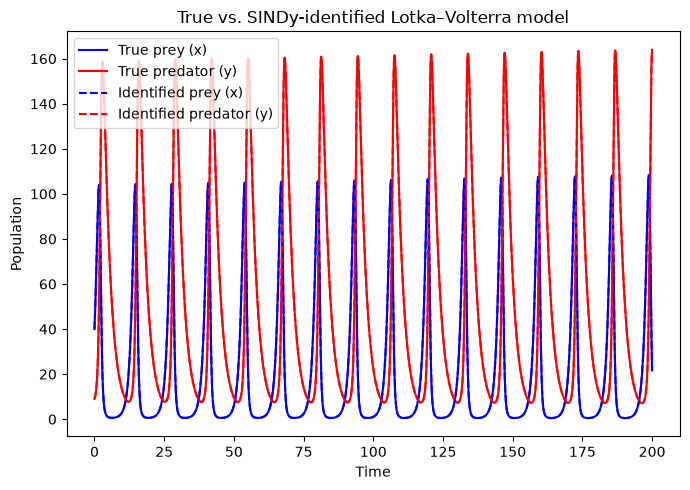

In [37]:
def simulate_identified(Xi, x0, y0, h, m):
    x_sim, y_sim = np.zeros(m), np.zeros(m)
    x_sim[0], y_sim[0] = x0, y0
    for i in range(m - 1):
        theta_row = np.array(lib_function(x_sim[i], y_sim[i]))
        dx, dy = theta_row @ Xi
        x_sim[i+1] = x_sim[i] + h * dx
        y_sim[i+1] = y_sim[i] + h * dy
    return x_sim, y_sim

x_sim, y_sim = simulate_identified(Xi_sparse, x[0], y[0], h, m)

traj_error = np.linalg.norm(np.vstack([x_sim, y_sim]) - np.vstack([x, y])) / np.linalg.norm(np.vstack([x, y]))
print(f'Relative trajectory error (identified vs. true): {traj_error:.5f}')

plt.figure(figsize=(7, 5))
plt.plot(t, x, 'b-',  label='True prey (x)')
plt.plot(t, y, 'r-',  label='True predator (y)')
plt.plot(t, x_sim, 'b--', label='Identified prey (x)')
plt.plot(t, y_sim, 'r--', label='Identified predator (y)')
plt.xlabel('Time'); plt.ylabel('Population')
plt.title('True vs. SINDy-identified Lotka–Volterra model')
plt.legend(); plt.tight_layout(); plt.show()

## 19. Sweep $\lambda$ to see the Pareto trade-off

This shows, across a range of $\lambda$, how the number of surviving terms and the
fit error both change — the "elbow"/plateau where the term count matches the true
model (4 nonzero terms total) while error stays low is the robust choice of $\lambda$.

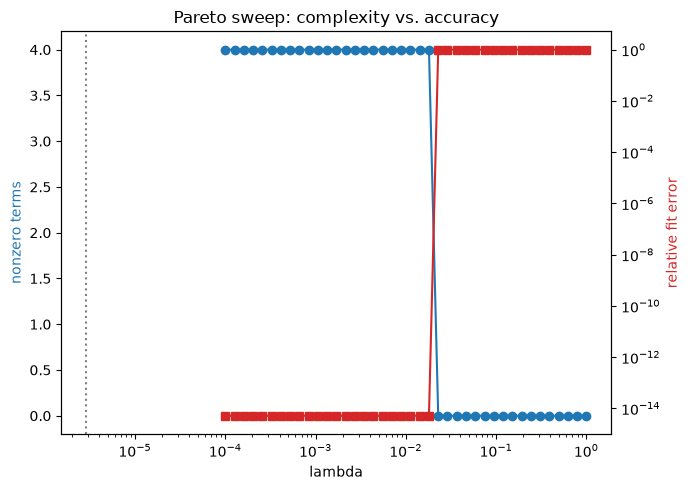

In [38]:
lambdas = np.logspace(-4, 0, 40)
n_terms_list, fit_err_list = [], []

for lam in lambdas:
    Xi_l = sparsify_dynamics(Theta, X_dot, lam)
    n_terms_list.append(np.count_nonzero(Xi_l))
    fit_err_list.append(np.linalg.norm(Theta @ Xi_l - X_dot) / np.linalg.norm(X_dot))

fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.set_xscale('log')
ax1.plot(lambdas, n_terms_list, 'o-', color='tab:blue')
ax1.set_xlabel('lambda'); ax1.set_ylabel('nonzero terms', color='tab:blue')

ax2 = ax1.twinx()
ax2.plot(lambdas, fit_err_list, 's-', color='tab:red')
ax2.set_yscale('log'); ax2.set_ylabel('relative fit error', color='tab:red')

plt.axvline(lambda_, color='gray', linestyle=':', label='chosen lambda')
plt.title('Pareto sweep: complexity vs. accuracy')
plt.tight_layout(); plt.show()